# Ejercicio 1.
Genera una imagen semejante a una diana de tiro al blanco como se aprecia en la imagen a continuación
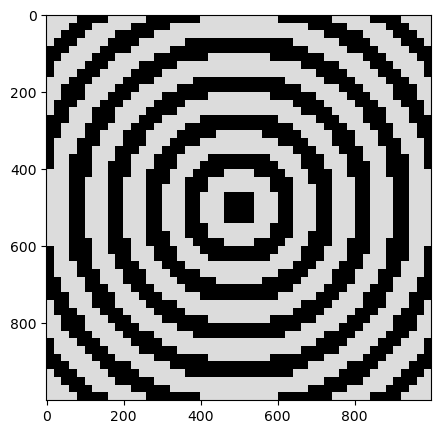


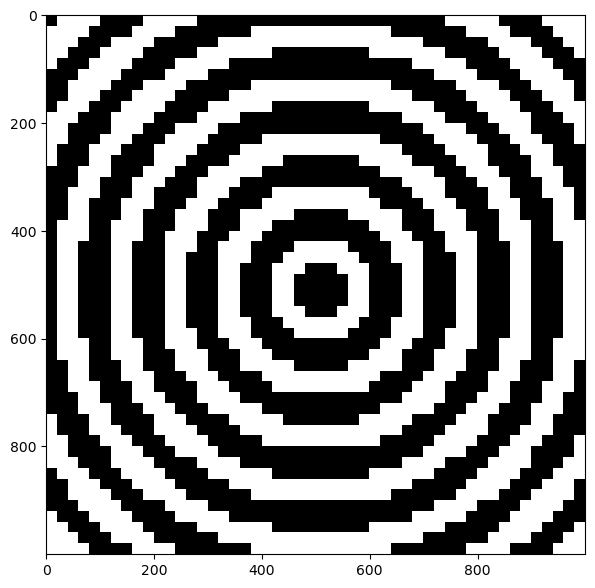

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n = 50
cx, cy = n // 2, n // 2

y, x = np.indices((n, n))
r = np.sqrt((x - cx)**2 + (y - cy)**2)

ancho_anillo = 2.5
imagen = ((r // ancho_anillo) % 2)

plt.figure(figsize=(7, 7))

plt.imshow(
    imagen,
    cmap='gray',
    interpolation='nearest',
    extent=[0, 1000, 1000, 0]
)
plt.xticks(np.arange(0, 801, 200))
plt.yticks(np.arange(0, 801, 200))

plt.imsave("puntoo.png", imagen, cmap="gray")
plt.show()

# Ejercicio 2.
Genera la imagen tal cual se muestra acontinuación, tomar en cuenta el tamaño 
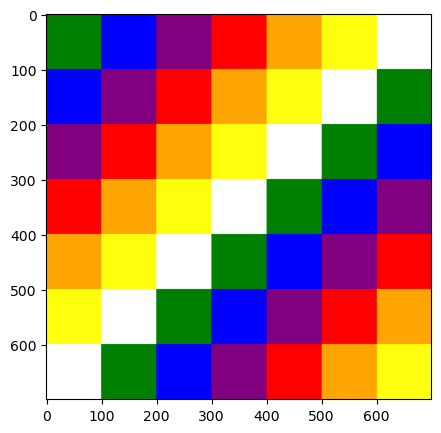

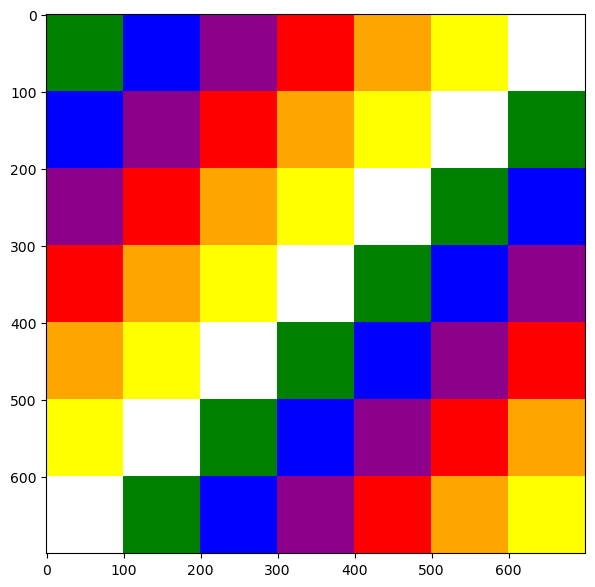

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

tamano= 700
bloque =  100
n= tamano // bloque

imagen = np.zeros((tamano, tamano, 3), dtype=np.uint8)

colores = [
    [0, 128, 0],[0, 0, 255],[140, 0, 140],[255, 0, 0],[255, 165, 0],[255, 255, 0],[255, 255, 255] 
]
for i in range (n):
    for j in range (n):
        color = colores[(i + j) % len(colores)]
        imagen[i*bloque:(i+1)*bloque, j*bloque:(j+1)*bloque] = color

plt.figure(figsize=(7, 7))
plt.imshow(imagen)



# Ejercicio 3.
Tomando en cuenta la imagen1.jpg elige un punto de interés al azar (funcion randomica), solariza y posteriza la imagen, realiza un tratamiento de umbralización(el de preferencia), mezcla tecnicas y obtiene un filtro artistico,lista todas las imágenes con sus correspondientes titulos, guarda todas las imágenes resultantes con sus nombres.

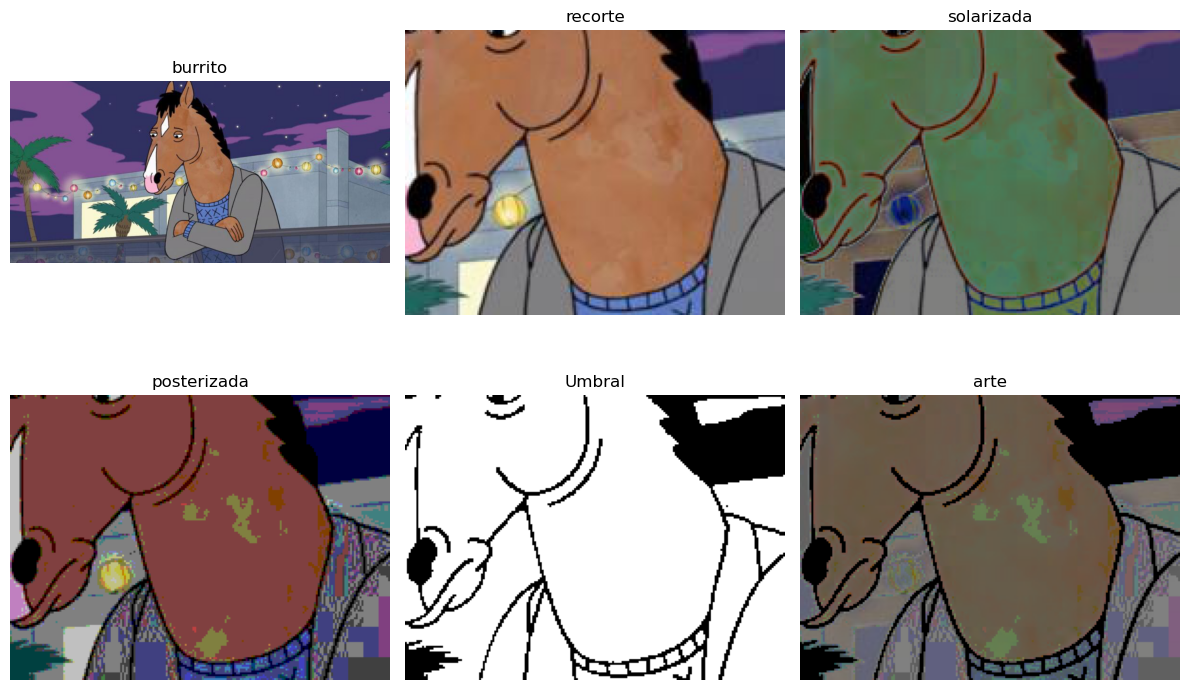

Recorte tomado en: x=302, y=118


In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

img = cv2.imread("burrito.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w, _ = img.shape

# recorte
recorte_ancho = 200
recorte_alto = 150

x = random.randint(0, w - recorte_ancho)
y = random.randint(0, h - recorte_alto)

recorte = img_rgb[y:y+recorte_alto, x:x+recorte_ancho]

# solarizado
solarizada = np.where(recorte < 128, recorte, 255 - recorte).astype(np.uint8)

# poster
niveles = 4
posterizada = (recorte // (256 // niveles)) * (256 // niveles)
posterizada = posterizada.astype(np.uint8)

# 5. Umbralizado
recorte_bgr = cv2.cvtColor(recorte, cv2.COLOR_RGB2BGR)
gray = cv2.cvtColor(recorte_bgr, cv2.COLOR_BGR2GRAY)

_, umbral_otsu = cv2.threshold(
    gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
# arte
mezcla = cv2.addWeighted(solarizada, 0.5, posterizada, 0.5, 0)
filtro_artistico = cv2.bitwise_and(mezcla, mezcla, mask=umbral_otsu)

cv2.imwrite("original.jpg", cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite("recorte.jpg", cv2.cvtColor(recorte, cv2.COLOR_RGB2BGR))
cv2.imwrite("solarizada.jpg", cv2.cvtColor(solarizada, cv2.COLOR_RGB2BGR))
cv2.imwrite("posterizada.jpg", cv2.cvtColor(posterizada, cv2.COLOR_RGB2BGR))
cv2.imwrite("umbral_otsu.jpg", umbral_otsu)
cv2.imwrite("filtro_artistico.jpg", cv2.cvtColor(filtro_artistico, cv2.COLOR_RGB2BGR))

titulos = [
    "burrito",
    "recorte",
    "solarizada",
    "posterizada",
    "Umbral",
    "arte"
]

imagenes = [
    img_rgb,
    recorte,
    solarizada,
    posterizada,
    umbral_otsu,
    filtro_artistico
]

plt.figure(figsize=(12,8))

for i in range(len(imagenes)):
    plt.subplot(2,3,i+1)
    if len(imagenes[i].shape) == 2:
        plt.imshow(imagenes[i], cmap='gray')
    else:
        plt.imshow(imagenes[i])
    plt.title(titulos[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Recorte tomado en: x={x}, y={y}")

# Ejercicio 4.
Genera un avatar, basandote en una imagen tuya que usaste en practicas anteriores, este avatar debe tener filtros y/o umbralizaciones.
Guarda la imagen 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


